In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

unit3_path = "/Users/tonyjaniak/Library/CloudStorage/OneDrive-UniversityofMissouri/CS4350/tmjg5h_Assignment2/Unit3_4_Data_All.xlsx"
unit4_path = "/Users/tonyjaniak/Library/CloudStorage/OneDrive-UniversityofMissouri/CS4350/tmjg5h_Assignment2/Unit4_Data_All.xlsx"

In [15]:
#Question 1

mobile = pd.read_excel(unit3_path, sheet_name="Mobile")

# 1a Rural: frequency + relative frequency
rural_freq = mobile["Rural"].value_counts(dropna=False).sort_index()
rural_rel = rural_freq / rural_freq.sum()

print("Rural Frequency:\n", rural_freq, "\n")
print("Rural Relative Frequency:\n", rural_rel, "\n")
print("Proportion Rural (Rural=1):", float(rural_rel.get(1, np.nan)))

Rural Frequency:
 Rural
0    54
1    26
Name: count, dtype: int64 

Rural Relative Frequency:
 Rural
0    0.675
1    0.325
Name: count, dtype: float64 

Proportion Rural (Rural=1): 0.325


In [16]:
# 1b College: frequency + relative frequency
college_freq = mobile["College"].value_counts(dropna=False).sort_index()
college_rel = college_freq / college_freq.sum()

print("\nCollege Frequency:\n", college_freq, "\n")
print("College Relative Frequency:\n", college_rel, "\n")
print("Proportion College (College=1):", float(college_rel.get(1, np.nan)))


College Frequency:
 College
0    24
1    56
Name: count, dtype: int64 

College Relative Frequency:
 College
0    0.3
1    0.7
Name: count, dtype: float64 

Proportion College (College=1): 0.7



Usage Frequency:
 Usage_Group
[0,60)       11
[60,120)     20
[120,180)    23
[180,240)    17
[240,300)     9
Name: count, dtype: int64 

Usage Relative Frequency:
 Usage_Group
[0,60)       0.1375
[60,120)     0.2500
[120,180)    0.2875
[180,240)    0.2125
[240,300)    0.1125
Name: count, dtype: float64 

Highest-frequency interval: [120,180)
Proportion Usage > 120: 0.6125


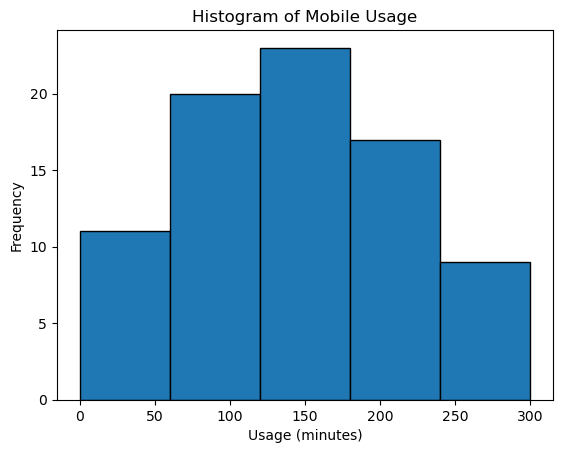

In [17]:
# 1c Usage bins (0-60, 60-120, ..., 240-300), left-closed right-open like R right=FALSE
bins = [0, 60, 120, 180, 240, 300]
labels = ["[0,60)", "[60,120)", "[120,180)", "[180,240)", "[240,300)"]

mobile["Usage_Group"] = pd.cut(
    mobile["Usage"],
    bins=bins,
    right=False,          # left-inclusive
    include_lowest=True,
    labels=labels
)

usage_freq = mobile["Usage_Group"].value_counts().reindex(labels)
usage_rel = usage_freq / usage_freq.sum()

print("\nUsage Frequency:\n", usage_freq, "\n")
print("Usage Relative Frequency:\n", usage_rel, "\n")

# Which interval has the highest frequency?
max_interval = usage_freq.idxmax()
print("Highest-frequency interval:", max_interval)

# Proportion using more than 120 minutes
prop_over_120 = (mobile["Usage"] > 120).mean()
print("Proportion Usage > 120:", float(prop_over_120))

# Histogram with the required breaks
plt.figure()
plt.hist(mobile["Usage"].dropna(), bins=bins, edgecolor="black")
plt.title("Histogram of Mobile Usage")
plt.xlabel("Usage (minutes)")
plt.ylabel("Frequency")
plt.show()

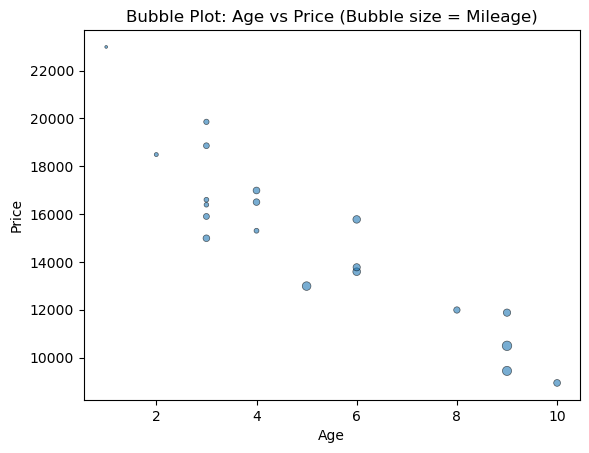

In [18]:
#Question 2

car = pd.read_excel(unit3_path, sheet_name="Car_Price")

#2a

plt.figure()
# scale bubble size so it's visible
sizes = car["Mileage"] / 2000  # adjust if needed
plt.scatter(car["Age"], car["Price"], s=sizes, alpha=0.6, edgecolors="black", linewidths=0.5)
plt.title("Bubble Plot: Age vs Price (Bubble size = Mileage)")
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()

In [19]:
#2b

car["Mileage_Category"] = np.where(car["Mileage"] < 50000, "Low_Mileage", "High_Mileage")
counts = car["Mileage_Category"].value_counts()
print(counts)
print("High_Mileage count:", int(counts.get("High_Mileage", 0)))

Mileage_Category
Low_Mileage     13
High_Mileage     7
Name: count, dtype: int64
High_Mileage count: 7


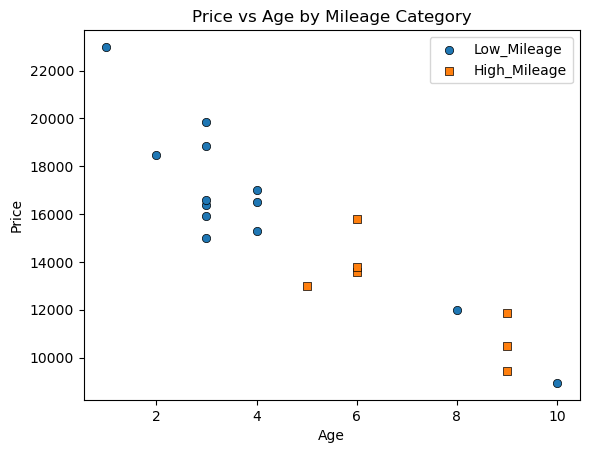

In [20]:
#2c

plt.figure()
for cat, marker in [("Low_Mileage", "o"), ("High_Mileage", "s")]:
    sub = car[car["Mileage_Category"] == cat]
    plt.scatter(sub["Age"], sub["Price"], marker=marker, label=cat, edgecolors="black", linewidths=0.5)

plt.title("Price vs Age by Mileage Category")
plt.xlabel("Age")
plt.ylabel("Price")
plt.legend()
plt.show()

In [21]:
#Question 4

mu1, sd1 = 0.08, 0.14   # risky
mu2, sd2 = 0.04, 0.05   # less risky

# 4a: minimize P(negative)

p_neg1 = stats.norm.cdf(0, loc=mu1, scale=sd1)
p_neg2 = stats.norm.cdf(0, loc=mu2, scale=sd2)

print("P(Risky < 0):", p_neg1)
print("P(Less risky < 0):", p_neg2)
print("Pick to minimize negative return:", "Less risky" if p_neg2 < p_neg1 else "Risky")

P(Risky < 0): 0.2838545830986763
P(Less risky < 0): 0.21185539858339675
Pick to minimize negative return: Less risky


In [22]:
# 4b: maximize P(return > 8%)

p_above8_1 = 1 - stats.norm.cdf(0.08, loc=mu1, scale=sd1)
p_above8_2 = 1 - stats.norm.cdf(0.08, loc=mu2, scale=sd2)

print("\nP(Risky > 0.08):", p_above8_1)
print("P(Less risky > 0.08):", p_above8_2)
print("Pick to maximize P(return > 8%):", "Risky" if p_above8_1 > p_above8_2 else "Less risky")


P(Risky > 0.08): 0.5
P(Less risky > 0.08): 0.21185539858339675
Pick to maximize P(return > 8%): Risky


In [23]:
#Question 5

p = 0.23

# 5a n=50, "more than 20%" => X > 10

n1 = 50
prob_50 = 1 - stats.binom.cdf(10, n1, p)
print("P(X>10) when n=50:", prob_50)

P(X>10) when n=50: 0.6209753731930902


In [24]:
# 5b n=200, "more than 20%" => X > 40

n2 = 200
prob_200 = 1 - stats.binom.cdf(40, n2, p)
print("P(X>40) when n=200:", prob_200)

P(X>40) when n=200: 0.8217579762195752


In [25]:
#Question 6 A & B

startups = pd.read_excel(unit4_path, sheet_name="Startups")

def t_ci(series, conf=0.95):
    x = series.dropna().to_numpy()
    n = len(x)
    xbar = x.mean()
    s = x.std(ddof=1)
    alpha = 1 - conf
    tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
    margin = tcrit * s / np.sqrt(n)
    return n, xbar, (xbar - margin, xbar + margin)

n_r, mean_r, ci_r = t_ci(startups["Research"], conf=0.95)
n_d, mean_d, ci_d = t_ci(startups["Duration"], conf=0.95)

print("Research: n =", n_r, "mean =", mean_r, "95% CI =", ci_r)
print("Duration: n =", n_d, "mean =", mean_d, "95% CI =", ci_d)

Research: n = 143 mean = 302.46688401398603 95% CI = (np.float64(231.4442815930298), np.float64(373.48948643494225))
Duration: n = 143 mean = 20.503496503496503 95% CI = (np.float64(18.40202746835397), np.float64(22.604965538639036))


In [26]:
#Question 7 A, B, & C

wait_time = pd.read_excel(unit4_path, sheet_name="Wait_Time")
x = wait_time["Time"].dropna().to_numpy()
n = len(x)
xbar = x.mean()
s = x.std(ddof=1)

mu0 = 5
t_stat = (xbar - mu0) / (s / np.sqrt(n))
p_value = 1 - stats.t.cdf(t_stat, df=n-1)  # right-tailed

print("n =", n)
print("mean =", xbar)
print("sd =", s)
print("t =", t_stat)
print("p-value (right-tailed) =", p_value)

alpha = 0.10
decision = "Reject H0 (hire)" if p_value < alpha else "Fail to reject H0 (do NOT hire)"
print("Decision at alpha=0.10:", decision)

n = 28
mean = 5.528571428571429
sd = 2.173724767554385
t = 1.2867025034706048
p-value (right-tailed) = 0.10456061374747794
Decision at alpha=0.10: Fail to reject H0 (do NOT hire)
